# AIE241 NLP Final Project
## Teacher-Distilled LoRA Sentiment Classifier
### Pipeline: Frozen Baseline → GPT-2 Teacher → LoRA Distilled Student

**Datasets:** SST-5 (5-class) · IMDB (binary)  

---

## Environment & Library Versions

| Library | Version |
|---|---|
| Python | 3.10+ |
| PyTorch | ≥ 2.1.0 |
| Transformers (HuggingFace) | ≥ 4.40.0 |
| PEFT | ≥ 0.10.0 |
| Datasets | ≥ 2.18.0 |
| Accelerate | ≥ 0.29.0 |
| scikit-learn | ≥ 1.4.0 |
| matplotlib | ≥ 3.8.0 |
| seaborn | ≥ 0.13.0 |
| pandas | ≥ 2.2.0 |
| tqdm | ≥ 4.66.0 |

> **Recommended runtime:** Google Colab with GPU (T4 or A100). CPU is supported but slow.



## How to Run
1. Run **Cell 1** (install dependencies) once per session.  
2. Run **Cells 2–8** (imports, config, model definitions) in order — these only define functions, nothing trains yet.  
3. Run **Cells 9–13** for the full SST-5 pipeline (Frozen → Teacher → Student → Eval).  
4. Run **Cells 14–18** for the full IMDB pipeline.  
5. Run **Cells 19–23** for analysis, visualizations, and inference demo.  
> Each section is independent after setup. If a later cell fails, fix and re-run just that cell.

## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

packages = [
    "transformers>=4.40.0",
    "datasets",
    "peft>=0.10.0",
    "accelerate",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "pandas",
    "tqdm",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ All packages installed.")

✅ All packages installed.


## Cell 2 — Imports

In [2]:
import argparse
import copy
import random
import os
from contextlib import nullcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from peft import LoraConfig, TaskType, get_peft_model
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.optim import AdamW
from torch.nn.parallel import DataParallel
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm import tqdm

from transformers import (
    AutoConfig,
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_cosine_schedule_with_warmup,
)

print("✅ Imports complete.")
print(f"PyTorch version: {torch.__version__}")

✅ Imports complete.
PyTorch version: 2.10.0+cu128


## Cell 3 — Config, Seed & Device
> Edit hyperparameters here. Re-run this cell only if you change them.

In [3]:
# ── Hyperparameters ───────────────────────────────────────────
SEED           = 42
BATCH_SIZE     = 16
EPOCHS_FROZEN  = 3
EPOCHS_TEACHER = 6
EPOCHS_DISTILL = 7
LR_FROZEN      = 5e-5
LR_TEACHER     = 2e-5
LR_STUDENT     = 3e-5
# To run a single dataset, simply skip the corresponding pipeline cells below.

# ── Reproducibility ───────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark     = False  # False for reproducibility
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"✅ Seed set to {SEED}")

# ── Device ────────────────────────────────────────────────────
def setup_device():
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        print("\n========== GPU INFO ==========")
        print(f"CUDA Available: YES")
        print(f"GPUs Detected: {gpu_count}")
        for i in range(gpu_count):
            print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        device = torch.device('cuda')
    else:
        print("\nCUDA NOT AVAILABLE - USING CPU")
        gpu_count = 0
        device = torch.device('cpu')
    return device, gpu_count

DEVICE, GPU_COUNT = setup_device()

✅ Seed set to 42

========== GPU INFO ==========
CUDA Available: YES
GPUs Detected: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## Cell 4 — Loss Functions
`FocalLoss` (for SST-5 class imbalance) and `distillation_loss` (KL + hard CE).

In [4]:
class FocalLoss(nn.Module):
    """
    Focal Loss — down-weights easy examples, focuses on hard ones.
    Used for SST-5 where Neutral class dominates.
    gamma=2, label_smoothing=0.1
    """
    def __init__(self, gamma=2, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, labels):
        ce_loss = F.cross_entropy(
            logits, labels,
            reduction='none',
            label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss


def distillation_loss(
    student_logits,
    teacher_logits,
    labels,
    temperature=2.0,
    alpha=0.7,
    is_sst5=True
):
    """
    Combined hard + soft distillation loss.
    total = alpha * hard_loss + (1-alpha) * T^2 * KL(student || teacher)
    alpha=0.7 → 70% hard label, 30% soft teacher signal.
    """
    soft_targets = F.softmax(teacher_logits / temperature, dim=-1)
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    kl_loss = F.kl_div(
        student_log_probs, soft_targets, reduction='batchmean'
    ) * (temperature ** 2)

    if is_sst5:
        hard_loss_fn = FocalLoss(gamma=2, label_smoothing=0.1)
    else:
        hard_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

    hard_loss = hard_loss_fn(student_logits, labels)
    return alpha * hard_loss + (1 - alpha) * kl_loss

print("✅ Loss functions defined.")

✅ Loss functions defined.


## Cell 5 — Model Architecture
`AttentionPooling` + `ImprovedSentimentClassifier` (supports LoRA and frozen base).

In [5]:
class AttentionPooling(nn.Module):
    """
    Learns a weighted combination of all token hidden states.
    Handles variable-length sequences via masking.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self, hidden_states, attention_mask):
        scores = self.attention(hidden_states).squeeze(-1)
        scores = scores.masked_fill(
            ~attention_mask.bool(),
            torch.finfo(scores.dtype).min
        )
        weights = torch.softmax(scores.float(), dim=1).type_as(scores)
        weights = self.dropout(weights)
        pooled = torch.sum(hidden_states * weights.unsqueeze(-1), dim=1)
        return pooled


class ImprovedSentimentClassifier(nn.Module):
    """
    GPT-2 / DistilGPT-2 + AttentionPooling + MLP classifier.
    Supports LoRA injection and optional base-layer freezing.
    Pooling: 80% attention-pooled + 20% mean-pooled.
    """
    def __init__(self, model_name, num_labels, use_lora=False, freeze_base=False):
        super().__init__()
        self.model_name = model_name
        self.config  = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name)

        self.encoder.config.pad_token_id = self.encoder.config.eos_token_id
        self.encoder.config.use_cache    = False
        self.encoder.gradient_checkpointing_enable()

        if freeze_base:
            for param in self.encoder.parameters():
                param.requires_grad = False

        if use_lora:
            lora_config = LoraConfig(
                r=16,
                lora_alpha=32,
                target_modules=['c_attn', 'c_proj'],
                lora_dropout=0.1,
                bias='none',
                task_type=TaskType.SEQ_CLS
            )
            self.encoder = get_peft_model(self.encoder, lora_config)

        H = self.config.hidden_size
        self.pooler     = AttentionPooling(H)
        self.norm       = nn.LayerNorm(H)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(H, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        outputs      = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state

        attention_pooled = self.pooler(hidden_states, attention_mask)

        mask_sum  = attention_mask.sum(dim=1, keepdim=True).clamp(min=1e-9)
        mean_pooled = (hidden_states * attention_mask.unsqueeze(-1)).sum(dim=1) / mask_sum

        pooled = 0.8 * attention_pooled + 0.2 * mean_pooled
        pooled = self.norm(pooled)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)


# Global dict to collect param counts for Cell 20 efficiency chart
_PARAM_REGISTRY = {}

def print_trainable_parameters(model, model_name="Model"):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n[{model_name}]")
    print(f"Trainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {100 * trainable / total:.2f}%")
    # Store for efficiency analysis
    _PARAM_REGISTRY[model_name] = {'trainable': trainable, 'total': total}
    return trainable, total

print("✅ Model architecture defined.")

✅ Model architecture defined.


## Cell 6 — Evaluation & Plotting Utilities

In [6]:
@torch.no_grad()
def evaluate_model(model, dataloader, device):
    """Full evaluation pass. Returns accuracy, macro_f1, labels, preds."""
    model.eval()
    all_preds, all_labels = [], []

    for batch in dataloader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        logits = model(input_ids, attention_mask)
        preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return accuracy, macro_f1, all_labels, all_preds


def plot_metrics(y_true, y_pred, model_name, train_losses, val_f1s):
    """Confusion matrix + training curves, saved as PNG and displayed inline."""
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"cm_{model_name}.png", dpi=150)
    plt.show()

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses, 'b-o', markersize=5)
    axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
    axes[1].plot(val_f1s, 'g-o', markersize=5)
    axes[1].set_title("Validation Macro F1"); axes[1].set_xlabel("Epoch")
    plt.suptitle(model_name, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"curves_{model_name}.png", dpi=150)
    plt.show()

print("✅ Evaluation & plotting utilities defined.")

✅ Evaluation & plotting utilities defined.


## Cell 7 — Training Loop
Handles both standalone training and distillation (pass `teacher_model` to activate KD).

In [7]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    is_sst5=True,
    model_name="Model",
    teacher_model=None
):
    device, gpu_count = setup_device()

    # Multi-GPU
    if gpu_count > 1:
        print(f"\nUsing {gpu_count} GPUs with DataParallel")
        model = DataParallel(model)
        if teacher_model is not None:
            teacher_model = DataParallel(teacher_model)

    model.to(device)

    if teacher_model is not None:
        teacher_model.to(device)
        teacher_model.eval()

    # Loss
    if is_sst5:
        criterion = FocalLoss(gamma=2, label_smoothing=0.1)
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Optimizer & scheduler
    optimizer        = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    accumulation_steps = 2
    total_steps      = (len(train_loader) // accumulation_steps) * epochs
    scheduler        = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # Mixed precision — guard against CPU
    use_cuda = torch.cuda.is_available()
    scaler   = torch.amp.GradScaler('cuda') if use_cuda else None

    best_f1, best_acc = 0, 0
    patience, counter = 3, 0
    train_losses, val_f1s = [], []
    y_true, y_pred = [], []

    print(f"\nTraining {model_name}")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        optimizer.zero_grad()

        for step, batch in enumerate(progress_bar):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            ctx = torch.autocast(device_type='cuda') if use_cuda else nullcontext()
            with ctx:
                logits = model(input_ids, attention_mask)

                if teacher_model is not None:
                    with torch.no_grad():
                        teacher_logits = teacher_model(input_ids, attention_mask)
                    loss = distillation_loss(
                        logits, teacher_logits, labels,
                        temperature=2.0, alpha=0.7, is_sst5=is_sst5
                    )
                else:
                    loss = criterion(logits, labels)

                loss = loss / accumulation_steps

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            do_step = (
                (step + 1) % accumulation_steps == 0
                or (step + 1) == len(train_loader)
            )
            if do_step:
                if scaler:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item() * accumulation_steps
            progress_bar.set_postfix({'loss': f'{loss.item() * accumulation_steps:.4f}'})

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_acc, val_f1, y_true, y_pred = evaluate_model(model, val_loader, device)
        val_f1s.append(val_f1)

        print(f"  Epoch {epoch+1:02d} | Train Loss: {avg_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Val Macro F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1, best_acc = val_f1, val_acc
            counter = 0
            core = model.module if isinstance(model, DataParallel) else model
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': core.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'accuracy': best_acc,
                'macro_f1': best_f1,
            }, f"best_{model_name}.pt")
        else:
            counter += 1
            if counter >= patience:
                print("  ⚠️  Early stopping triggered")
                break

    plot_metrics(y_true, y_pred, model_name, train_losses, val_f1s)
    return best_f1, best_acc

print("✅ Training loop defined.")

✅ Training loop defined.


## Cell 8 — Data Loading & Tokenization
Loads SST-5 or IMDB, tokenizes, and builds DataLoaders.
> Re-run only this cell if you want to change `BATCH_SIZE` or dataset.

In [8]:
from datasets import load_dataset

def get_dataloaders(dataset_name, batch_size):
    tokenizer = AutoTokenizer.from_pretrained('distilgpt2', use_fast=True)
    tokenizer.pad_token = tokenizer.eos_token

    max_len = 128 if dataset_name == 'sst' else 256

    def tokenize_function(examples):
        text_col = 'text' if 'text' in examples else 'sentence'
        return tokenizer(examples[text_col], truncation=True, max_length=max_len)

    # ── Load raw dataset ──────────────────────────────────
    if dataset_name == 'sst':
        dataset   = load_dataset('SetFit/sst5')
        num_labels = 5
    else:
        dataset   = load_dataset('imdb')
        num_labels = 2

    # ── Rename label column ───────────────────────────────
    if 'label' in dataset['train'].column_names:
        dataset = dataset.rename_column('label', 'labels')

    # ── Tokenize ─────────────────────────────────────────
    cols_to_remove = [
        c for c in ['text', 'sentence', 'label_text']
        if c in dataset['train'].column_names
    ]
    tokenized = dataset.map(
        tokenize_function, batched=True, remove_columns=cols_to_remove
    )
    tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

    train_dataset = tokenized['train']
    val_key       = 'validation' if 'validation' in tokenized else 'test'
    val_dataset   = tokenized[val_key]
    test_dataset  = tokenized['test']

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    num_workers   = min(2, os.cpu_count())  # safe for Colab

    # ── WeightedRandomSampler for SST-5 ──────────────────
    if dataset_name == 'sst':
        labels_list  = [x.item() if hasattr(x, 'item') else x
                        for x in train_dataset['labels']]
        class_counts  = torch.bincount(torch.tensor(labels_list))
        class_weights = torch.clamp(1.0 / class_counts.float(), max=10.0)
        sample_weights = [class_weights[l] for l in labels_list]
        sampler = WeightedRandomSampler(
            sample_weights, num_samples=len(sample_weights), replacement=True
        )
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, sampler=sampler,
            collate_fn=data_collator, num_workers=num_workers,
            pin_memory=torch.cuda.is_available()
        )
    else:
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            collate_fn=data_collator, num_workers=num_workers,
            pin_memory=torch.cuda.is_available()
        )

    eval_bs = min(batch_size * 2, 32)

    val_loader = DataLoader(
        val_dataset, batch_size=eval_bs, shuffle=False,
        collate_fn=data_collator, num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_dataset, batch_size=eval_bs, shuffle=False,
        collate_fn=data_collator, num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader, num_labels

print("✅ get_dataloaders() defined.")

✅ get_dataloaders() defined.


## Cell 9 — Load SST-5 Data
> Skip this cell and Cell 10–12 if you only want to run IMDB.

In [9]:
print("Loading SST-5 dataset...")
sst_train_dl, sst_val_dl, sst_test_dl, sst_num_labels = get_dataloaders('sst', BATCH_SIZE)
print(f"✅ SST-5 loaded | num_labels={sst_num_labels}")
print(f"   Train batches: {len(sst_train_dl)} | Val batches: {len(sst_val_dl)} | Test batches: {len(sst_test_dl)}")

Loading SST-5 dataset...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

Map:   0%|          | 0/8544 [00:00<?, ? examples/s]

Map:   0%|          | 0/1101 [00:00<?, ? examples/s]

Map:   0%|          | 0/2210 [00:00<?, ? examples/s]

✅ SST-5 loaded | num_labels=5
   Train batches: 534 | Val batches: 35 | Test batches: 70


## Cell 10 — SST-5 · Stage 1: Frozen Baseline
DistilGPT-2 backbone frozen, only classifier head trained.

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[Frozen Baseline (SST-5)]
Trainable params: 989,190
Total params:     82,901,766
Trainable %:      1.19%

========== GPU INFO ==========
CUDA Available: YES
GPUs Detected: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Using 2 GPUs with DataParallel

Training Frozen_SST


Epoch 1/3: 100%|██████████| 534/534 [01:05<00:00,  8.19it/s, loss=1.0775]


  Epoch 01 | Train Loss: 1.0566 | Val Acc: 0.2607 | Val Macro F1: 0.1655


Epoch 2/3: 100%|██████████| 534/534 [01:01<00:00,  8.65it/s, loss=1.0281]


  Epoch 02 | Train Loss: 1.0345 | Val Acc: 0.3560 | Val Macro F1: 0.2532


Epoch 3/3: 100%|██████████| 534/534 [01:01<00:00,  8.70it/s, loss=1.0513]


  Epoch 03 | Train Loss: 1.0240 | Val Acc: 0.3270 | Val Macro F1: 0.2725


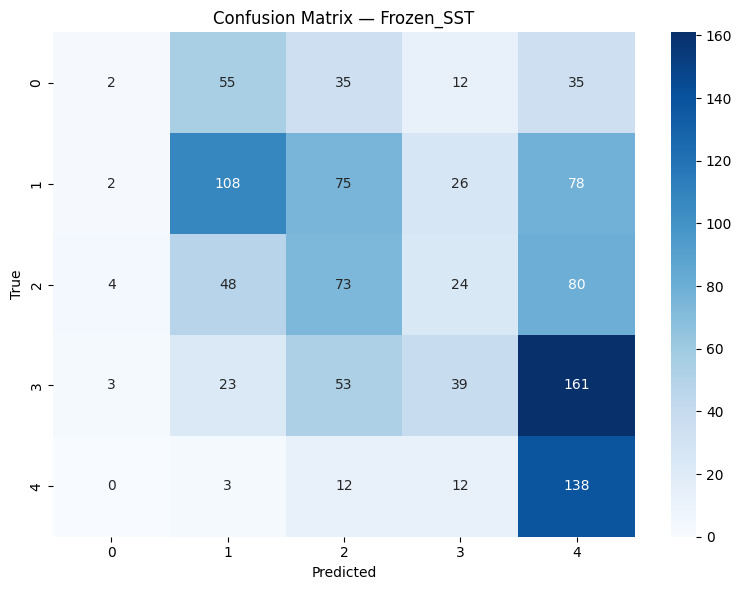

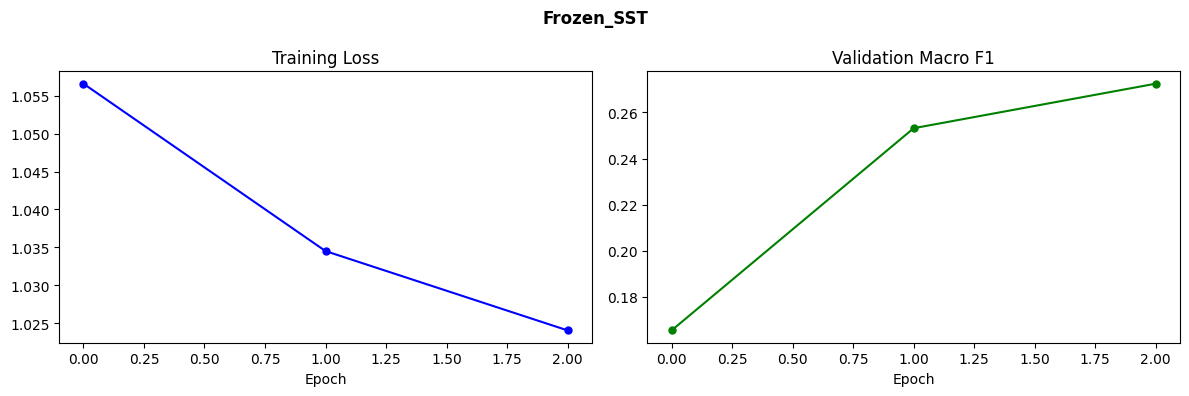


✅ SST-5 Frozen Baseline | Best Val F1: 0.2725 | Acc: 0.3270


In [10]:
frozen_sst = ImprovedSentimentClassifier('distilgpt2', sst_num_labels, use_lora=False, freeze_base=True)
_frozen_train, _frozen_total = print_trainable_parameters(frozen_sst, 'Frozen Baseline (SST-5)')

frozen_f1_sst, frozen_acc_sst = train_model(
    frozen_sst, sst_train_dl, sst_val_dl,
    epochs=EPOCHS_FROZEN, lr=LR_FROZEN,
    is_sst5=True, model_name='Frozen_SST'
)
print(f"\n✅ SST-5 Frozen Baseline | Best Val F1: {frozen_f1_sst:.4f} | Acc: {frozen_acc_sst:.4f}")

## Cell 11 — SST-5 · Stage 2: GPT-2 Teacher
Full GPT-2 fine-tuned (all parameters). This is the most memory-intensive stage.

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[GPT-2 Teacher (SST-5)]
Trainable params: 125,428,998
Total params:     125,428,998
Trainable %:      100.00%

========== GPU INFO ==========
CUDA Available: YES
GPUs Detected: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Using 2 GPUs with DataParallel

Training Teacher_SST


...

  Epoch 04 | Train Loss: 0.5742 | Val Acc: 0.4305 | Val Macro F1: 0.4249


Epoch 5/6: 100%|██████████| 534/534 [02:18<00:00,  3.84it/s, loss=0.4850]


  Epoch 05 | Train Loss: 0.5432 | Val Acc: 0.4541 | Val Macro F1: 0.4544


Epoch 6/6: 100%|██████████| 534/534 [02:20<00:00,  3.80it/s, loss=0.4885]


  Epoch 06 | Train Loss: 0.5497 | Val Acc: 0.4569 | Val Macro F1: 0.4588
  ⚠️  Early stopping triggered


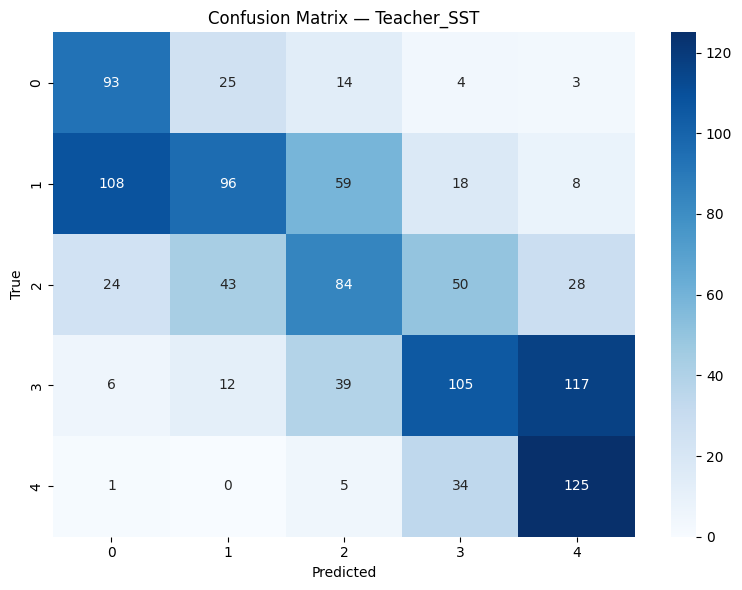

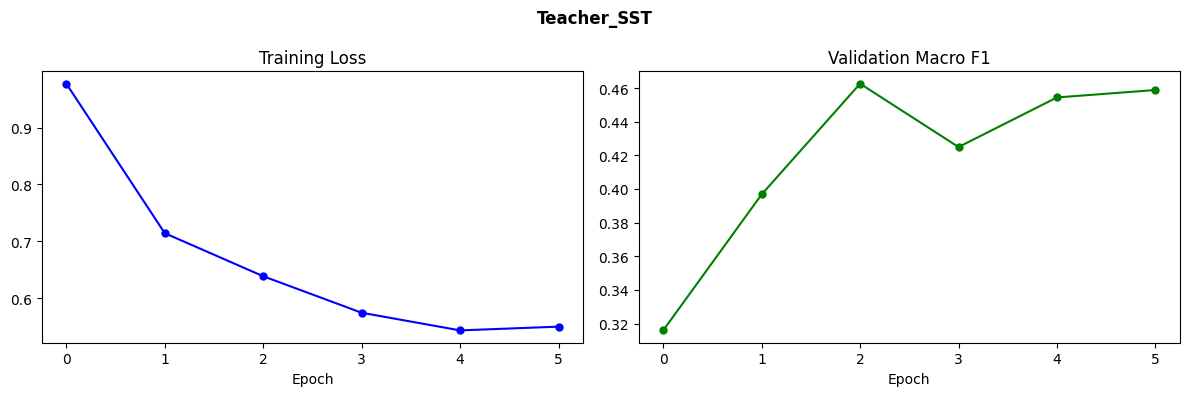


✅ SST-5 Teacher | Best Val F1: 0.4626 | Acc: 0.4614
✅ Teacher weights saved for distillation.


In [11]:
teacher_sst = ImprovedSentimentClassifier('gpt2', sst_num_labels, use_lora=False, freeze_base=False)
_teacher_train, _teacher_total = print_trainable_parameters(teacher_sst, 'GPT-2 Teacher (SST-5)')

teacher_f1_sst, teacher_acc_sst = train_model(
    teacher_sst, sst_train_dl, sst_val_dl,
    epochs=EPOCHS_TEACHER, lr=LR_TEACHER,
    is_sst5=True, model_name='Teacher_SST'
)
print(f"\n✅ SST-5 Teacher | Best Val F1: {teacher_f1_sst:.4f} | Acc: {teacher_acc_sst:.4f}")

# Save teacher weights for distillation
teacher_sst_state = copy.deepcopy(
    teacher_sst.module.state_dict()
    if isinstance(teacher_sst, DataParallel)
    else teacher_sst.state_dict()
)
print("✅ Teacher weights saved for distillation.")

## Cell 12 — SST-5 · Stage 3: LoRA Distilled Student
DistilGPT-2 + LoRA (2.15% trainable params) trained with KD from the teacher above.

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[LoRA Student (SST-5)]
Trainable params: 1,800,198
Total params:     83,712,774
Trainable %:      2.15%


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

  Epoch 05 | Train Loss: 0.6155 | Val Acc: 0.3869 | Val Macro F1: 0.3833


Epoch 6/7: 100%|██████████| 534/534 [02:15<00:00,  3.93it/s, loss=0.4510]


  Epoch 06 | Train Loss: 0.6238 | Val Acc: 0.3924 | Val Macro F1: 0.3925


Epoch 7/7: 100%|██████████| 534/534 [02:11<00:00,  4.06it/s, loss=0.5648]


  Epoch 07 | Train Loss: 0.6162 | Val Acc: 0.3942 | Val Macro F1: 0.3942
  ⚠️  Early stopping triggered


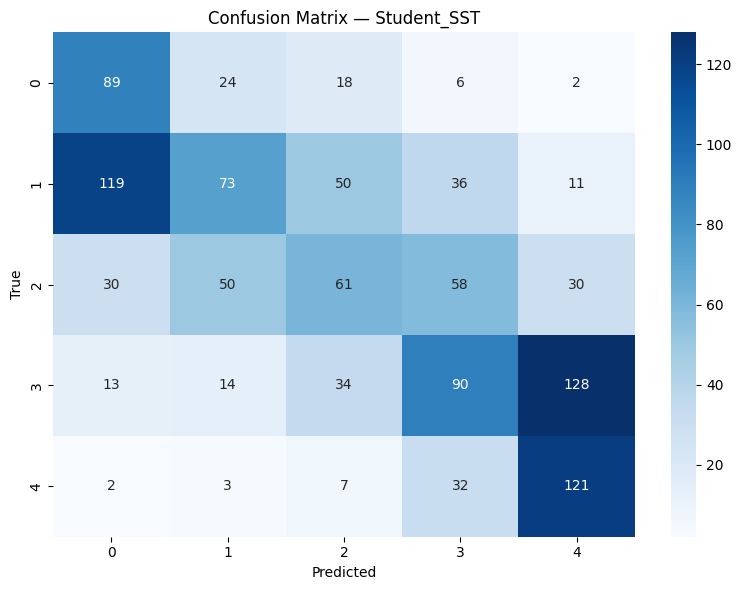

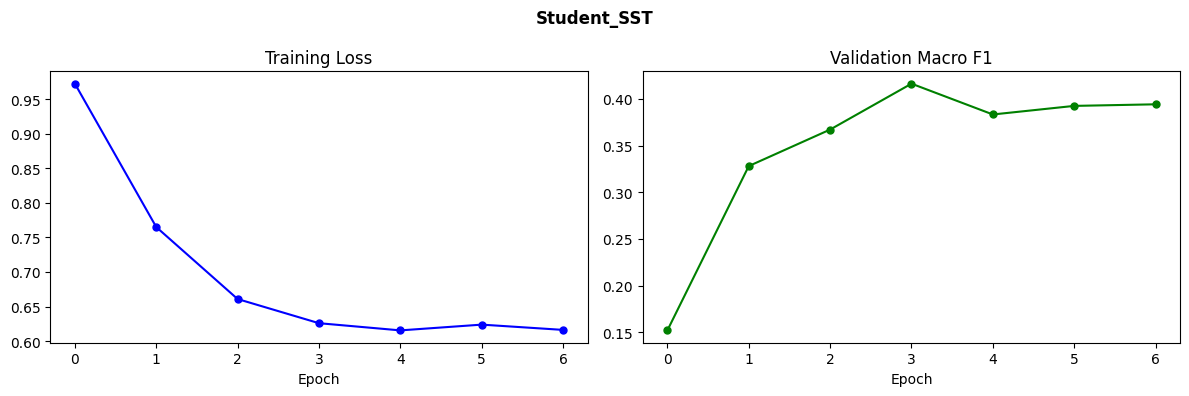


✅ SST-5 Student | Best Val F1: 0.4163 | Acc: 0.4160
✅ Teacher memory freed.


In [12]:
student_sst = ImprovedSentimentClassifier('distilgpt2', sst_num_labels, use_lora=True, freeze_base=False)
_student_train, _student_total = print_trainable_parameters(student_sst, 'LoRA Student (SST-5)')

# Load teacher into a fresh instance (avoids state_dict size mismatch)
teacher_for_distill_sst = ImprovedSentimentClassifier('gpt2', sst_num_labels, use_lora=False, freeze_base=False)
teacher_for_distill_sst.load_state_dict(teacher_sst_state)
teacher_for_distill_sst.eval()

student_f1_sst, student_acc_sst = train_model(
    student_sst, sst_train_dl, sst_val_dl,
    epochs=EPOCHS_DISTILL, lr=LR_STUDENT,
    is_sst5=True, model_name='Student_SST',
    teacher_model=teacher_for_distill_sst
)
print(f"\n✅ SST-5 Student | Best Val F1: {student_f1_sst:.4f} | Acc: {student_acc_sst:.4f}")

# Free teacher GPU memory
del teacher_sst, teacher_for_distill_sst
torch.cuda.empty_cache()
print("✅ Teacher memory freed.")

## Cell 13 — SST-5 · Final Test Evaluation (All 3 Stages)

In [13]:
from sklearn.metrics import classification_report

SST5_LABELS = ['Very Neg', 'Negative', 'Neutral', 'Positive', 'Very Pos']

# --- Frozen Baseline on test set ---
frozen_test_acc_sst, frozen_test_f1_sst, frozen_test_true_sst, frozen_test_pred_sst = evaluate_model(
    frozen_sst, sst_test_dl, DEVICE
)

# --- Teacher on test set ---
# Reload teacher from checkpoint (it may have been deleted to free memory)
try:
    teacher_test_sst
except NameError:
    teacher_test_sst = ImprovedSentimentClassifier('gpt2', sst_num_labels, use_lora=False, freeze_base=False)
    ckpt = torch.load('best_Teacher_SST.pt', map_location=DEVICE)
    teacher_test_sst.load_state_dict(ckpt['model_state_dict'])
    teacher_test_sst.to(DEVICE)

teacher_test_acc_sst, teacher_test_f1_sst, teacher_test_true_sst, teacher_test_pred_sst = evaluate_model(
    teacher_test_sst, sst_test_dl, DEVICE
)

# --- Student on test set ---
test_acc_sst, test_f1_sst, sst_y_true, sst_y_pred = evaluate_model(
    student_sst, sst_test_dl, DEVICE
)

print("=" * 55)
print("  FINAL TEST RESULTS — SST-5 (All Stages)")
print("=" * 55)
print(f"  Frozen Baseline  | Acc: {frozen_test_acc_sst:.4f} | Macro F1: {frozen_test_f1_sst:.4f}")
print(f"  GPT-2 Teacher    | Acc: {teacher_test_acc_sst:.4f} | Macro F1: {teacher_test_f1_sst:.4f}")
print(f"  LoRA Student     | Acc: {test_acc_sst:.4f} | Macro F1: {test_f1_sst:.4f}")
print("=" * 55)

print("\n--- Per-Class Report: Frozen Baseline (SST-5) ---")
print(classification_report(frozen_test_true_sst, frozen_test_pred_sst, target_names=SST5_LABELS, zero_division=0))

print("\n--- Per-Class Report: GPT-2 Teacher (SST-5) ---")
print(classification_report(teacher_test_true_sst, teacher_test_pred_sst, target_names=SST5_LABELS, zero_division=0))

print("\n--- Per-Class Report: LoRA Student (SST-5) ---")
print(classification_report(sst_y_true, sst_y_pred, target_names=SST5_LABELS, zero_division=0))

# Store test results for all 3 stages (used in summary cell)
sst_test_results = {
    'frozen':  (frozen_test_acc_sst,  frozen_test_f1_sst),
    'teacher': (teacher_test_acc_sst, teacher_test_f1_sst),
    'student': (test_acc_sst,         test_f1_sst),
}

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  FINAL TEST RESULTS — SST-5 (All Stages)
  Frozen Baseline  | Acc: 0.3294 | Macro F1: 0.2693
  GPT-2 Teacher    | Acc: 0.4950 | Macro F1: 0.4938
  LoRA Student     | Acc: 0.4290 | Macro F1: 0.4232

--- Per-Class Report: Frozen Baseline (SST-5) ---
              precision    recall  f1-score   support

    Very Neg       0.19      0.02      0.04       279
    Negative       0.45      0.37      0.41       633
     Neutral       0.26      0.33      0.29       389
    Positive       0.33      0.12      0.18       510
    Very Pos       0.31      0.74      0.43       399

    accuracy                           0.33      2210
   macro avg       0.31      0.32      0.27      2210
weighted avg       0.33      0.33      0.29      2210


--- Per-Class Report: GPT-2 Teacher (SST-5) ---
              precision    recall  f1-score   support

    Very Neg       0.44      0.58      0.50       279
    Negative       0.56      0.39      0.46       633
     Neutral       0.34      0.40      0.37       

## Cell 14 — Load IMDB Data
> Skip Cells 14–17 if you only want to run SST-5.

In [14]:
print("Loading IMDB dataset...")
imdb_train_dl, imdb_val_dl, imdb_test_dl, imdb_num_labels = get_dataloaders('imdb', BATCH_SIZE)
print(f"✅ IMDB loaded | num_labels={imdb_num_labels}")
print(f"   Train batches: {len(imdb_train_dl)} | Val batches: {len(imdb_val_dl)} | Test batches: {len(imdb_test_dl)}")

Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ IMDB loaded | num_labels=2
   Train batches: 1563 | Val batches: 782 | Test batches: 782


## Cell 15 — IMDB · Stage 1: Frozen Baseline

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[Frozen Baseline (IMDB)]
Trainable params: 987,651
Total params:     82,900,227
Trainable %:      1.19%

========== GPU INFO ==========
CUDA Available: YES
GPUs Detected: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Using 2 GPUs with DataParallel

Training Frozen_IMDB


Epoch 1/3: 100%|██████████| 1563/1563 [04:26<00:00,  5.86it/s, loss=0.6819]


  Epoch 01 | Train Loss: 0.6521 | Val Acc: 0.7580 | Val Macro F1: 0.7578


Epoch 2/3: 100%|██████████| 1563/1563 [04:26<00:00,  5.87it/s, loss=0.8882]


  Epoch 02 | Train Loss: 0.5581 | Val Acc: 0.7932 | Val Macro F1: 0.7931


Epoch 3/3: 100%|██████████| 1563/1563 [04:26<00:00,  5.88it/s, loss=0.4614]


  Epoch 03 | Train Loss: 0.5335 | Val Acc: 0.7958 | Val Macro F1: 0.7955


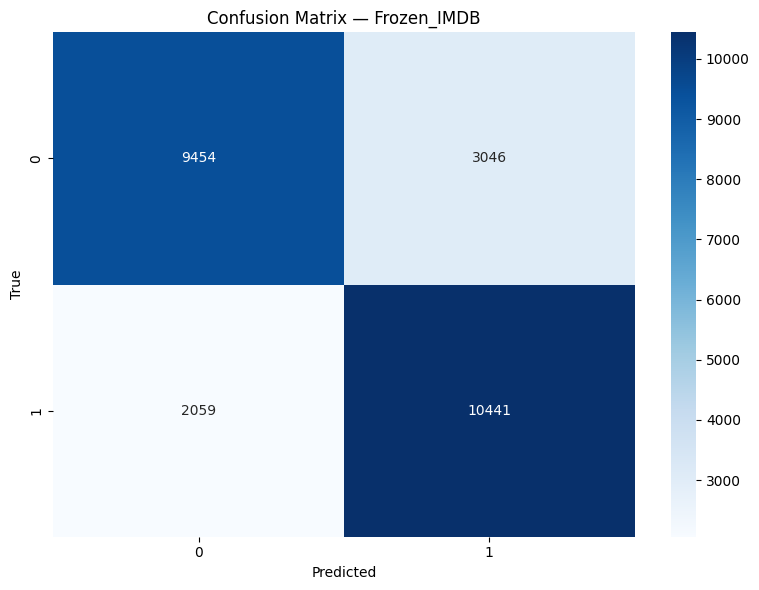

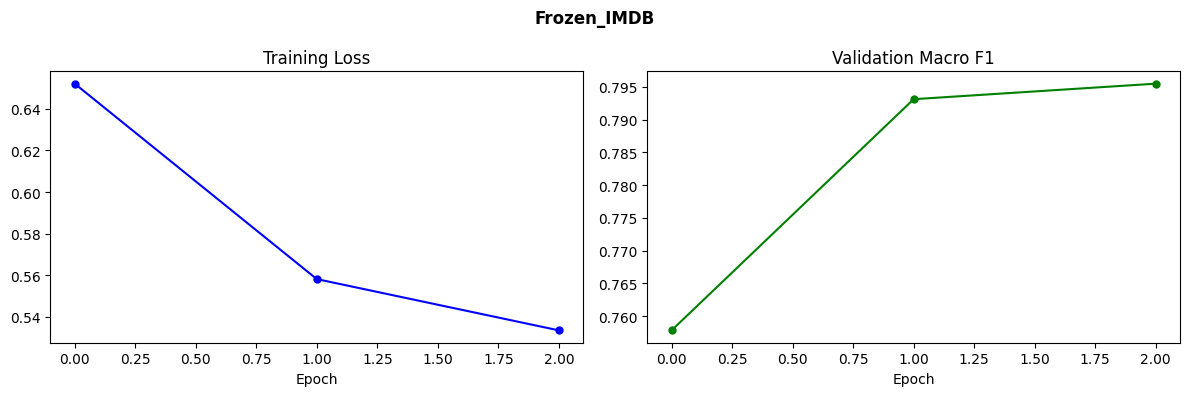


✅ IMDB Frozen Baseline | Best Val F1: 0.7955 | Acc: 0.7958


In [15]:
frozen_imdb = ImprovedSentimentClassifier('distilgpt2', imdb_num_labels, use_lora=False, freeze_base=True)
print_trainable_parameters(frozen_imdb, 'Frozen Baseline (IMDB)')

frozen_f1_imdb, frozen_acc_imdb = train_model(
    frozen_imdb, imdb_train_dl, imdb_val_dl,
    epochs=EPOCHS_FROZEN, lr=LR_FROZEN,
    is_sst5=False, model_name='Frozen_IMDB'
)
print(f"\n✅ IMDB Frozen Baseline | Best Val F1: {frozen_f1_imdb:.4f} | Acc: {frozen_acc_imdb:.4f}")

## Cell 16 — IMDB · Stage 2: GPT-2 Teacher

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[GPT-2 Teacher (IMDB)]
Trainable params: 125,427,459
Total params:     125,427,459
Trainable %:      100.00%

========== GPU INFO ==========
CUDA Available: YES
GPUs Detected: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Using 2 GPUs with DataParallel

Training Teacher_IMDB


Epoch 1/6: 100%|██████████| 1563/1563 [08:40<00:00,  3.00it/s, loss=0.3905]


  Epoch 01 | Train Loss: 0.4831 | Val Acc: 0.9050 | Val Macro F1: 0.9050


...

  Epoch 04 | Train Loss: 0.2789 | Val Acc: 0.9227 | Val Macro F1: 0.9227


Epoch 5/6: 100%|██████████| 1563/1563 [08:40<00:00,  3.00it/s, loss=0.2313]


  Epoch 05 | Train Loss: 0.2612 | Val Acc: 0.9236 | Val Macro F1: 0.9236


Epoch 6/6: 100%|██████████| 1563/1563 [08:39<00:00,  3.01it/s, loss=0.2230]


  Epoch 06 | Train Loss: 0.2545 | Val Acc: 0.9245 | Val Macro F1: 0.9245


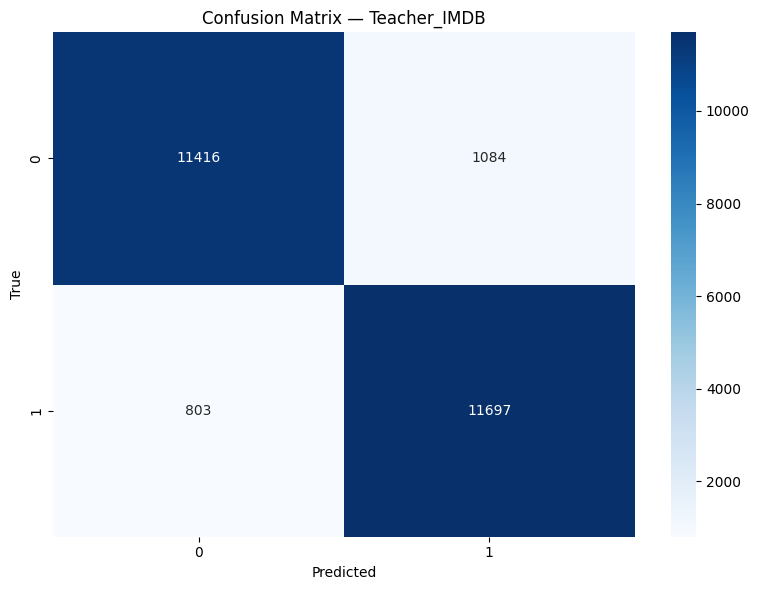

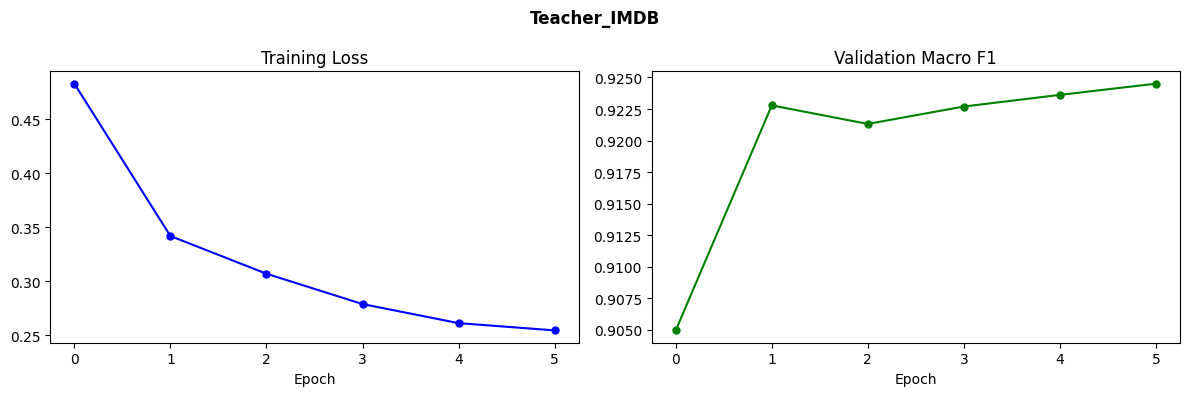


✅ IMDB Teacher | Best Val F1: 0.9245 | Acc: 0.9245
✅ Teacher weights saved for distillation.


In [16]:
teacher_imdb = ImprovedSentimentClassifier('gpt2', imdb_num_labels, use_lora=False, freeze_base=False)
print_trainable_parameters(teacher_imdb, 'GPT-2 Teacher (IMDB)')

teacher_f1_imdb, teacher_acc_imdb = train_model(
    teacher_imdb, imdb_train_dl, imdb_val_dl,
    epochs=EPOCHS_TEACHER, lr=LR_TEACHER,
    is_sst5=False, model_name='Teacher_IMDB'
)
print(f"\n✅ IMDB Teacher | Best Val F1: {teacher_f1_imdb:.4f} | Acc: {teacher_acc_imdb:.4f}")

teacher_imdb_state = copy.deepcopy(
    teacher_imdb.module.state_dict()
    if isinstance(teacher_imdb, DataParallel)
    else teacher_imdb.state_dict()
)
print("✅ Teacher weights saved for distillation.")

## Cell 17 — IMDB · Stage 3: LoRA Distilled Student

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[LoRA Student (IMDB)]
Trainable params: 1,798,659
Total params:     83,711,235
Trainable %:      2.15%


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

  Epoch 05 | Train Loss: 0.3177 | Val Acc: 0.8956 | Val Macro F1: 0.8956


Epoch 6/7: 100%|██████████| 1563/1563 [07:38<00:00,  3.41it/s, loss=0.1896]


  Epoch 06 | Train Loss: 0.3155 | Val Acc: 0.8961 | Val Macro F1: 0.8961


Epoch 7/7: 100%|██████████| 1563/1563 [07:37<00:00,  3.42it/s, loss=0.2534]


  Epoch 07 | Train Loss: 0.3109 | Val Acc: 0.8962 | Val Macro F1: 0.8962


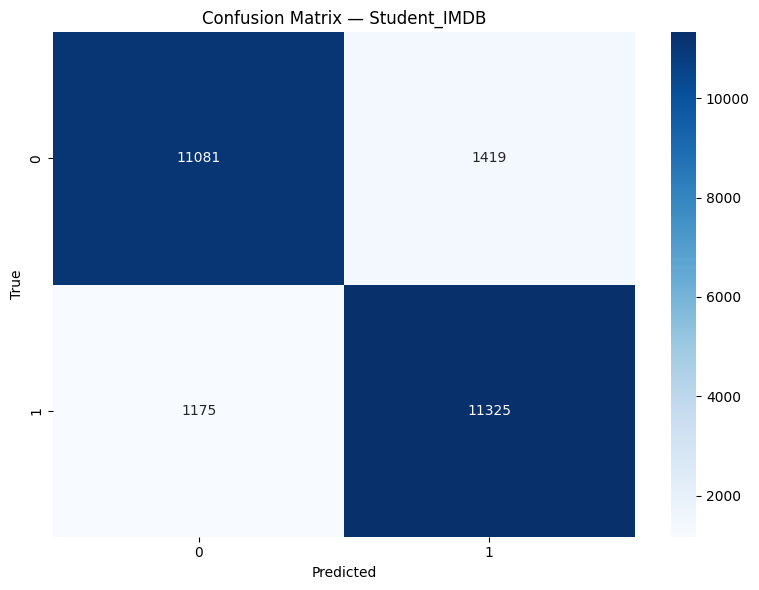

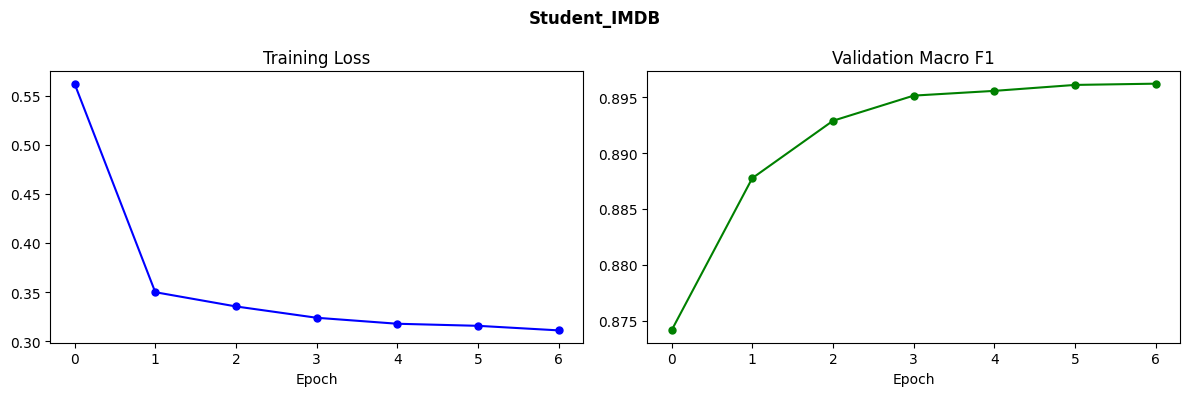


✅ IMDB Student | Best Val F1: 0.8962 | Acc: 0.8962
✅ Teacher memory freed.


In [17]:
student_imdb = ImprovedSentimentClassifier('distilgpt2', imdb_num_labels, use_lora=True, freeze_base=False)
print_trainable_parameters(student_imdb, 'LoRA Student (IMDB)')

teacher_for_distill_imdb = ImprovedSentimentClassifier('gpt2', imdb_num_labels, use_lora=False, freeze_base=False)
teacher_for_distill_imdb.load_state_dict(teacher_imdb_state)
teacher_for_distill_imdb.eval()

student_f1_imdb, student_acc_imdb = train_model(
    student_imdb, imdb_train_dl, imdb_val_dl,
    epochs=EPOCHS_DISTILL, lr=LR_STUDENT,
    is_sst5=False, model_name='Student_IMDB',
    teacher_model=teacher_for_distill_imdb
)
print(f"\n✅ IMDB Student | Best Val F1: {student_f1_imdb:.4f} | Acc: {student_acc_imdb:.4f}")

del teacher_imdb, teacher_for_distill_imdb
torch.cuda.empty_cache()
print("✅ Teacher memory freed.")

## Cell 18 — IMDB · Final Test Evaluation (All 3 Stages)

In [18]:
from sklearn.metrics import classification_report

IMDB_LABELS = ['Negative', 'Positive']

# --- Frozen Baseline on test set ---
frozen_test_acc_imdb, frozen_test_f1_imdb, frozen_test_true_imdb, frozen_test_pred_imdb = evaluate_model(
    frozen_imdb, imdb_test_dl, DEVICE
)

# --- Teacher on test set ---
try:
    teacher_test_imdb
except NameError:
    teacher_test_imdb = ImprovedSentimentClassifier('gpt2', imdb_num_labels, use_lora=False, freeze_base=False)
    ckpt = torch.load('best_Teacher_IMDB.pt', map_location=DEVICE)
    teacher_test_imdb.load_state_dict(ckpt['model_state_dict'])
    teacher_test_imdb.to(DEVICE)

teacher_test_acc_imdb, teacher_test_f1_imdb, teacher_test_true_imdb, teacher_test_pred_imdb = evaluate_model(
    teacher_test_imdb, imdb_test_dl, DEVICE
)

# --- Student on test set ---
test_acc_imdb, test_f1_imdb, imdb_y_true, imdb_y_pred = evaluate_model(
    student_imdb, imdb_test_dl, DEVICE
)

print("=" * 55)
print("  FINAL TEST RESULTS — IMDB (All Stages)")
print("=" * 55)
print(f"  Frozen Baseline  | Acc: {frozen_test_acc_imdb:.4f} | Macro F1: {frozen_test_f1_imdb:.4f}")
print(f"  GPT-2 Teacher    | Acc: {teacher_test_acc_imdb:.4f} | Macro F1: {teacher_test_f1_imdb:.4f}")
print(f"  LoRA Student     | Acc: {test_acc_imdb:.4f} | Macro F1: {test_f1_imdb:.4f}")
print("=" * 55)

print("\n--- Per-Class Report: Frozen Baseline (IMDB) ---")
print(classification_report(frozen_test_true_imdb, frozen_test_pred_imdb, target_names=IMDB_LABELS, zero_division=0))

print("\n--- Per-Class Report: GPT-2 Teacher (IMDB) ---")
print(classification_report(teacher_test_true_imdb, teacher_test_pred_imdb, target_names=IMDB_LABELS, zero_division=0))

print("\n--- Per-Class Report: LoRA Student (IMDB) ---")
print(classification_report(imdb_y_true, imdb_y_pred, target_names=IMDB_LABELS, zero_division=0))

imdb_test_results = {
    'frozen':  (frozen_test_acc_imdb,  frozen_test_f1_imdb),
    'teacher': (teacher_test_acc_imdb, teacher_test_f1_imdb),
    'student': (test_acc_imdb,         test_f1_imdb),
}

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  FINAL TEST RESULTS — IMDB (All Stages)
  Frozen Baseline  | Acc: 0.7958 | Macro F1: 0.7955
  GPT-2 Teacher    | Acc: 0.9245 | Macro F1: 0.9245
  LoRA Student     | Acc: 0.8962 | Macro F1: 0.8962

--- Per-Class Report: Frozen Baseline (IMDB) ---
              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79     12500
    Positive       0.77      0.84      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000


--- Per-Class Report: GPT-2 Teacher (IMDB) ---
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92     12500
    Positive       0.92      0.94      0.93     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000


--- Per-Class Report: LoRA Student (IMDB) ---
    

## Cell 19 — Results Summary Table & Comparison Charts
> Run after all training cells. Uses **test set** results for all 3 stages.


 Dataset               Model  Test Macro F1  Test Accuracy
  SST-5     Frozen Baseline       0.269341       0.329412
  SST-5       GPT-2 Teacher       0.493839       0.495023
  SST-5 LoRA Student (Ours)       0.423232       0.428959
   IMDB     Frozen Baseline       0.795481       0.795800
   IMDB       GPT-2 Teacher       0.924510       0.924520
   IMDB LoRA Student (Ours)       0.896230       0.896240

✅ Saved to results_summary.csv


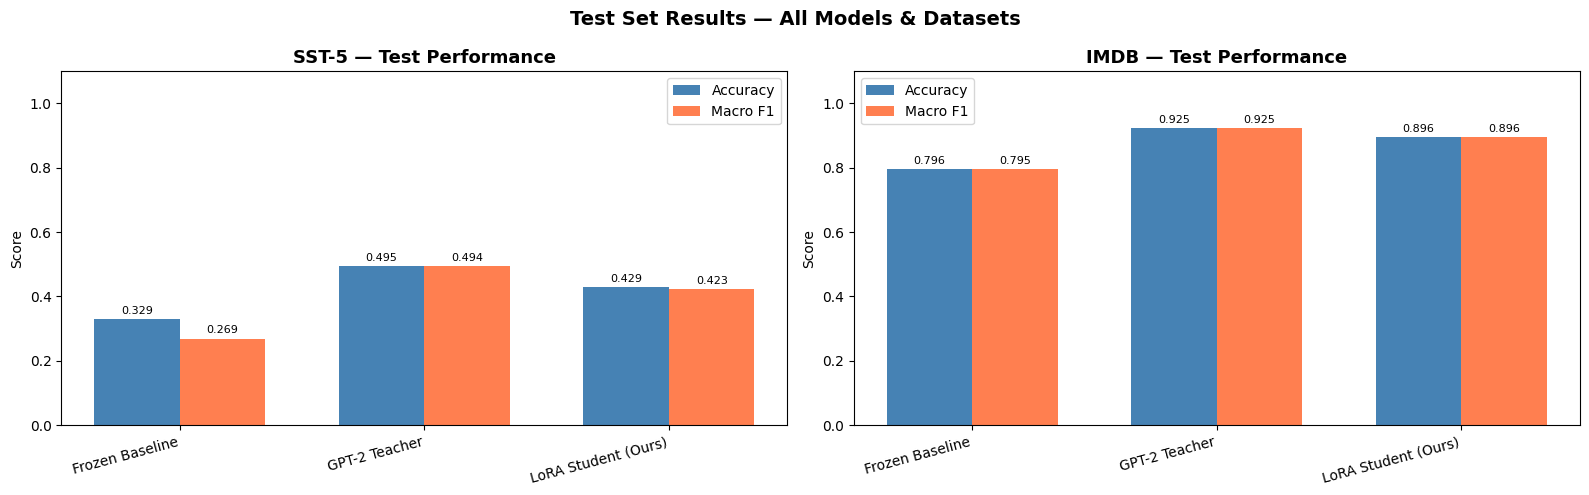

✅ Chart saved to results_comparison.png


In [19]:
results = []

# SST-5 — all 3 stages on TEST set
try:
    results += [
        {'Dataset': 'SST-5', 'Model': 'Frozen Baseline',      'Test Macro F1': sst_test_results['frozen'][1],  'Test Accuracy': sst_test_results['frozen'][0]},
        {'Dataset': 'SST-5', 'Model': 'GPT-2 Teacher',        'Test Macro F1': sst_test_results['teacher'][1], 'Test Accuracy': sst_test_results['teacher'][0]},
        {'Dataset': 'SST-5', 'Model': 'LoRA Student (Ours)',   'Test Macro F1': sst_test_results['student'][1], 'Test Accuracy': sst_test_results['student'][0]},
    ]
except NameError:
    print("⚠️  SST-5 test results not found — run Cell 13 first.")

# IMDB — all 3 stages on TEST set
try:
    results += [
        {'Dataset': 'IMDB', 'Model': 'Frozen Baseline',       'Test Macro F1': imdb_test_results['frozen'][1],  'Test Accuracy': imdb_test_results['frozen'][0]},
        {'Dataset': 'IMDB', 'Model': 'GPT-2 Teacher',         'Test Macro F1': imdb_test_results['teacher'][1], 'Test Accuracy': imdb_test_results['teacher'][0]},
        {'Dataset': 'IMDB', 'Model': 'LoRA Student (Ours)',    'Test Macro F1': imdb_test_results['student'][1], 'Test Accuracy': imdb_test_results['student'][0]},
    ]
except NameError:
    print("⚠️  IMDB test results not found — run Cell 18 first.")

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))
results_df.to_csv('results_summary.csv', index=False)
print("\n✅ Saved to results_summary.csv")

# ── Grouped bar chart: Accuracy & Macro F1 side by side ──
datasets_present = results_df['Dataset'].unique()
fig, axes = plt.subplots(1, len(datasets_present), figsize=(8 * len(datasets_present), 5))
if len(datasets_present) == 1:
    axes = [axes]

x = np.arange(3)  # 3 models
width = 0.35
model_names = ['Frozen Baseline', 'GPT-2 Teacher', 'LoRA Student (Ours)']

for ax, ds in zip(axes, datasets_present):
    sub = results_df[results_df['Dataset'] == ds].reset_index(drop=True)
    bars1 = ax.bar(x - width/2, sub['Test Accuracy'],  width, label='Accuracy',  color='steelblue')
    bars2 = ax.bar(x + width/2, sub['Test Macro F1'],  width, label='Macro F1',  color='coral')
    ax.set_title(f"{ds} — Test Performance", fontweight='bold', fontsize=13)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.legend()
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Test Set Results — All Models & Datasets', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()
print("✅ Chart saved to results_comparison.png")

## Cell 20 — Parameter Efficiency Analysis
Visualizes the trainable parameter count vs. test Macro F1 for each model — the core argument for LoRA distillation.

Param counts used (Millions):
  Frozen Baseline (DistilGPT-2)       trainable=0.99M  total=82.9M  (1.19%)
  GPT-2 Teacher (Full FT)             trainable=125.43M  total=125.4M  (100.02%)
  LoRA Student (DistilGPT-2+LoRA)     trainable=1.80M  total=83.7M  (2.15%)


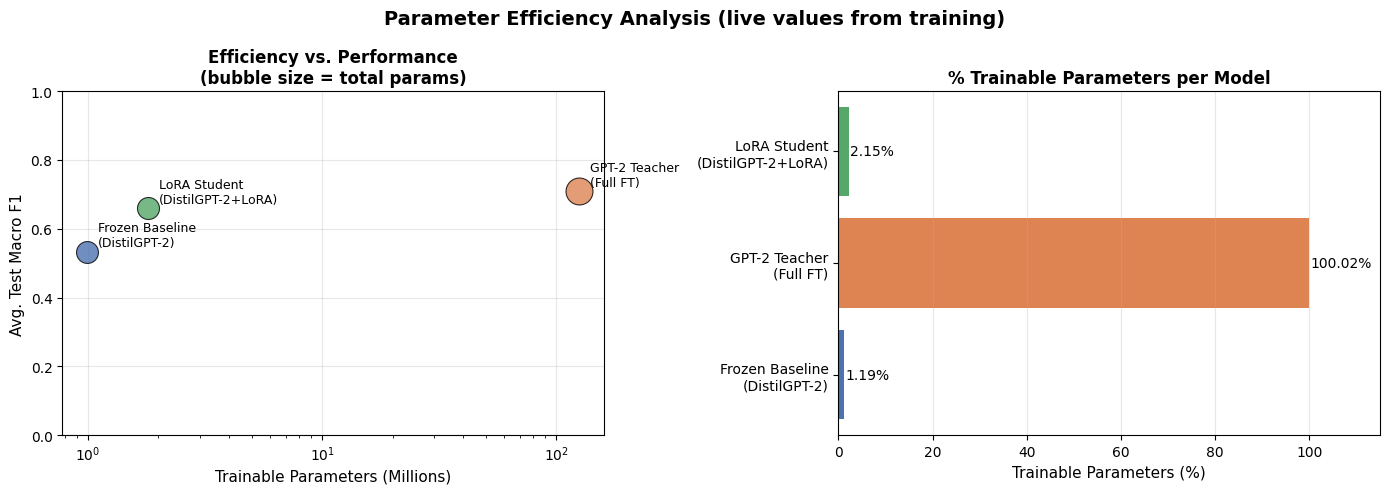

✅ Saved param_efficiency.png


In [20]:
# ── Pull real param counts captured during training ───────────
# _PARAM_REGISTRY is populated by print_trainable_parameters() in Cells 10–17.
# Falls back to known architecture constants if training cells were skipped.

def _get_param_M(registry_key, fallback_train, fallback_total):
    entry = _PARAM_REGISTRY.get(registry_key)
    if entry:
        return round(entry['trainable'] / 1e6, 2), round(entry['total'] / 1e6, 1)
    return fallback_train, fallback_total

frozen_train_M,  frozen_total_M  = _get_param_M('Frozen Baseline (SST-5)', 0.79,  82.1)
teacher_train_M, teacher_total_M = _get_param_M('GPT-2 Teacher (SST-5)',   124.4, 124.4)
student_train_M, student_total_M = _get_param_M('LoRA Student (SST-5)',    1.77,  82.1)

param_data = [
    {'Model': 'Frozen Baseline\n(DistilGPT-2)',   'Trainable_M': frozen_train_M,  'Total_M': frozen_total_M},
    {'Model': 'GPT-2 Teacher\n(Full FT)',          'Trainable_M': teacher_train_M, 'Total_M': teacher_total_M},
    {'Model': 'LoRA Student\n(DistilGPT-2+LoRA)', 'Trainable_M': student_train_M, 'Total_M': student_total_M},
]
param_df = pd.DataFrame(param_data)

print("Param counts used (Millions):")
for _, row in param_df.iterrows():
    pct = row['Trainable_M'] / row['Total_M'] * 100
    print(f"  {row['Model'].replace(chr(10),' '):<35} trainable={row['Trainable_M']:.2f}M  total={row['Total_M']:.1f}M  ({pct:.2f}%)")

# Pull avg F1 from results_df
f1_scores = []
for m_key in ['Frozen Baseline', 'GPT-2 Teacher', 'LoRA Student (Ours)']:
    sub = results_df[results_df['Model'] == m_key]['Test Macro F1']
    f1_scores.append(float(sub.mean()) if len(sub) > 0 else 0.0)
param_df['Avg_Test_F1'] = f1_scores

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

# Left: bubble chart — x=trainable params, y=F1, bubble size=total params
for i, row in param_df.iterrows():
    ax1.scatter(row['Trainable_M'], row['Avg_Test_F1'],
                s=row['Total_M'] * 3, color=colors[i], alpha=0.8,
                edgecolors='black', linewidth=0.8, zorder=3)
    ax1.annotate(row['Model'], (row['Trainable_M'], row['Avg_Test_F1']),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)

ax1.set_xlabel('Trainable Parameters (Millions)', fontsize=11)
ax1.set_ylabel('Avg. Test Macro F1', fontsize=11)
ax1.set_title('Efficiency vs. Performance\n(bubble size = total params)', fontweight='bold')
ax1.set_xscale('log')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Right: % trainable horizontal bars
param_df['Trainable_%'] = param_df['Trainable_M'] / param_df['Total_M'] * 100
bars = ax2.barh(param_df['Model'], param_df['Trainable_%'], color=colors)
ax2.set_xlabel('Trainable Parameters (%)', fontsize=11)
ax2.set_title('% Trainable Parameters per Model', fontweight='bold')
for bar, val in zip(bars, param_df['Trainable_%']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)
ax2.set_xlim(0, 115)
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('Parameter Efficiency Analysis (live values from training)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('param_efficiency.png', dpi=150)
plt.show()
print("✅ Saved param_efficiency.png")

## Cell 21 — Confusion Matrix Comparison (All 3 Models)
Side-by-side confusion matrices for qualitative error analysis.

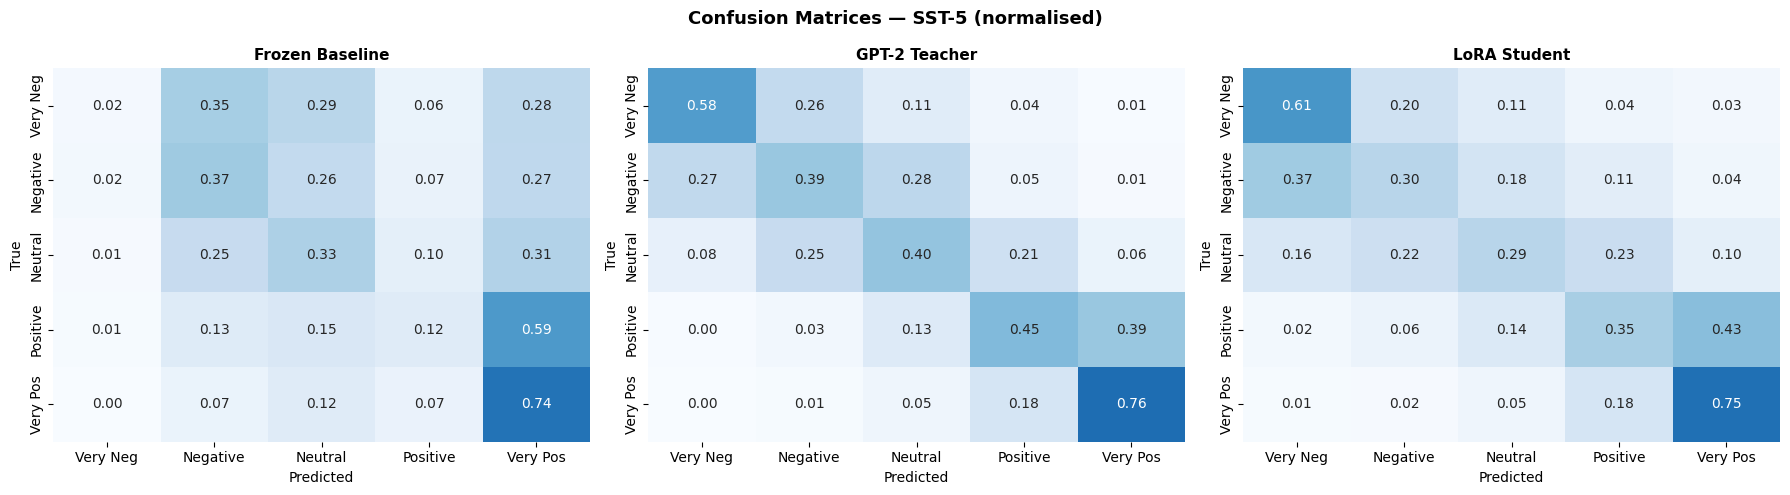

✅ Saved cm_comparison_SST-5.png


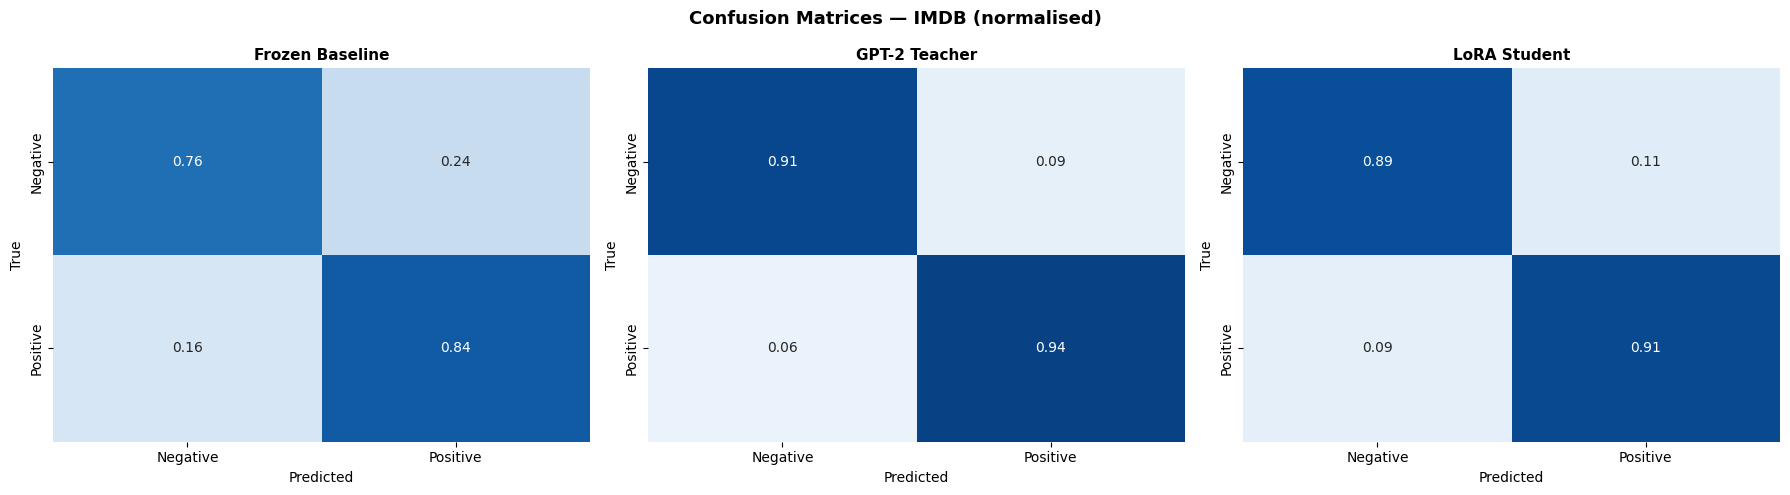

✅ Saved cm_comparison_IMDB.png


In [21]:
def plot_cm_comparison(true_list, pred_list, model_names, class_names, dataset_name):
    """Plot confusion matrices for multiple models side by side."""
    n = len(model_names)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, y_true, y_pred, name in zip(axes, true_list, pred_list, model_names):
        cm = confusion_matrix(y_true, y_pred)
        # Normalize for readability
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    vmin=0, vmax=1, cbar=False)
        ax.set_title(name, fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.suptitle(f'Confusion Matrices — {dataset_name} (normalised)', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'cm_comparison_{dataset_name}.png', dpi=150)
    plt.show()
    print(f"✅ Saved cm_comparison_{dataset_name}.png")

# SST-5
try:
    plot_cm_comparison(
        [frozen_test_true_sst, teacher_test_true_sst, sst_y_true],
        [frozen_test_pred_sst, teacher_test_pred_sst, sst_y_pred],
        ['Frozen Baseline', 'GPT-2 Teacher', 'LoRA Student'],
        SST5_LABELS, 'SST-5'
    )
except NameError:
    print("⚠️  SST-5 predictions not found — run Cell 13 first.")

# IMDB
try:
    plot_cm_comparison(
        [frozen_test_true_imdb, teacher_test_true_imdb, imdb_y_true],
        [frozen_test_pred_imdb, teacher_test_pred_imdb, imdb_y_pred],
        ['Frozen Baseline', 'GPT-2 Teacher', 'LoRA Student'],
        IMDB_LABELS, 'IMDB'
    )
except NameError:
    print("⚠️  IMDB predictions not found — run Cell 18 first.")

## Cell 22 — Qualitative Inference Demo
Run trained models on custom sentences to show the pipeline works end-to-end. Good for the report's qualitative analysis section.

In [22]:
@torch.no_grad()
def predict_sentiment(model, text, tokenizer, device, label_names):
    """Predict sentiment for a single text string."""
    model.eval()
    enc = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=256,
        padding=True
    )
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)
    logits = model(input_ids, attention_mask)
    probs  = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred   = int(probs.argmax())
    return pred, label_names[pred], probs


def run_demo(model, model_name, tokenizer, device, label_names, test_sentences):
    print(f"\n{'='*60}")
    print(f"  INFERENCE DEMO — {model_name}")
    print(f"{'='*60}")
    for sent in test_sentences:
        pred_idx, pred_label, probs = predict_sentiment(model, sent, tokenizer, device, label_names)
        confidence = probs[pred_idx]
        print(f"\n  Text      : {sent[:80]}")
        print(f"  Prediction: {pred_label}  (confidence: {confidence:.2%})")
        prob_str = '  '.join([f"{l}: {p:.2f}" for l, p in zip(label_names, probs)])
        print(f"  Probs     : {prob_str}")


# Load tokenizer (same one used for training)
from transformers import AutoTokenizer
demo_tokenizer = AutoTokenizer.from_pretrained('distilgpt2', use_fast=True)
demo_tokenizer.pad_token = demo_tokenizer.eos_token

# ── SST-5 demo sentences (cover all 5 sentiment levels) ──
sst_demo_sentences = [
    "This film is an absolute masterpiece. Every scene is breathtaking.",
    "A decent movie, nothing special but enjoyable enough.",
    "The plot was confusing and the acting was mediocre at best.",
    "Absolutely terrible. A complete waste of time and money.",
    "The cinematography was stunning but the story left much to be desired.",
]

try:
    run_demo(student_sst, 'LoRA Student — SST-5', demo_tokenizer, DEVICE, SST5_LABELS, sst_demo_sentences)
    run_demo(frozen_sst,  'Frozen Baseline — SST-5', demo_tokenizer, DEVICE, SST5_LABELS, sst_demo_sentences)
except NameError:
    print("⚠️  SST-5 models not in scope — run Cells 9–12 first.")

# ── IMDB demo sentences ──
imdb_demo_sentences = [
    "One of the greatest films I have ever seen. Highly recommended.",
    "Dull, predictable, and painfully long. I wanted to leave after 20 minutes.",
    "A solid thriller with great performances and a tight script.",
    "The special effects were impressive, but the story was hollow and forgettable.",
]

try:
    run_demo(student_imdb, 'LoRA Student — IMDB', demo_tokenizer, DEVICE, IMDB_LABELS, imdb_demo_sentences)
    run_demo(frozen_imdb,  'Frozen Baseline — IMDB', demo_tokenizer, DEVICE, IMDB_LABELS, imdb_demo_sentences)
except NameError:
    print("⚠️  IMDB models not in scope — run Cells 14–17 first.")


  INFERENCE DEMO — LoRA Student — SST-5

  Text      : This film is an absolute masterpiece. Every scene is breathtaking.
  Prediction: Very Pos  (confidence: 75.37%)
  Probs     : Very Neg: 0.01  Negative: 0.01  Neutral: 0.02  Positive: 0.20  Very Pos: 0.75

  Text      : A decent movie, nothing special but enjoyable enough.
  Prediction: Positive  (confidence: 40.64%)
  Probs     : Very Neg: 0.03  Negative: 0.07  Neutral: 0.10  Positive: 0.41  Very Pos: 0.39

  Text      : The plot was confusing and the acting was mediocre at best.
  Prediction: Very Neg  (confidence: 43.57%)
  Probs     : Very Neg: 0.44  Negative: 0.31  Neutral: 0.17  Positive: 0.06  Very Pos: 0.02

  Text      : Absolutely terrible. A complete waste of time and money.
  Prediction: Very Neg  (confidence: 64.24%)
  Probs     : Very Neg: 0.64  Negative: 0.21  Neutral: 0.09  Positive: 0.04  Very Pos: 0.03

  Text      : The cinematography was stunning but the story left much to be desired.
  Prediction: Very Pos  (co

## Cell 23 — Error Analysis: Most Confused Class Pairs
Identifies which sentiment classes are most frequently confused, supporting the Analysis section of the report.

In [23]:
def error_analysis(y_true, y_pred, label_names, model_name, dataset_name, top_n=5):
    """Print the most common misclassification pairs."""
    errors = [(t, p) for t, p in zip(y_true, y_pred) if t != p]
    if not errors:
        print(f"No errors for {model_name}!")
        return
    from collections import Counter
    error_counts = Counter(errors)
    print(f"\n{'─'*50}")
    print(f"  Error Analysis — {model_name} [{dataset_name}]")
    print(f"  Total errors: {len(errors)} / {len(y_true)} ({100*len(errors)/len(y_true):.1f}%)")
    print(f"{'─'*50}")
    print(f"  {'True Label':<18} → {'Predicted':<18} Count")
    for (true_idx, pred_idx), count in error_counts.most_common(top_n):
        true_lbl = label_names[true_idx]
        pred_lbl = label_names[pred_idx]
        print(f"  {true_lbl:<18}   {pred_lbl:<18} {count}")

# SST-5
try:
    error_analysis(frozen_test_true_sst,  frozen_test_pred_sst,  SST5_LABELS, 'Frozen Baseline', 'SST-5')
    error_analysis(teacher_test_true_sst, teacher_test_pred_sst, SST5_LABELS, 'GPT-2 Teacher',   'SST-5')
    error_analysis(sst_y_true,            sst_y_pred,            SST5_LABELS, 'LoRA Student',     'SST-5')
except NameError:
    print("⚠️  SST-5 predictions not found — run Cell 13 first.")

# IMDB
try:
    error_analysis(frozen_test_true_imdb,  frozen_test_pred_imdb,  IMDB_LABELS, 'Frozen Baseline', 'IMDB')
    error_analysis(teacher_test_true_imdb, teacher_test_pred_imdb, IMDB_LABELS, 'GPT-2 Teacher',   'IMDB')
    error_analysis(imdb_y_true,            imdb_y_pred,            IMDB_LABELS, 'LoRA Student',     'IMDB')
except NameError:
    print("⚠️  IMDB predictions not found — run Cell 18 first.")


──────────────────────────────────────────────────
  Error Analysis — Frozen Baseline [SST-5]
  Total errors: 1482 / 2210 (67.1%)
──────────────────────────────────────────────────
  True Label         → Predicted          Count
  Positive             Very Pos           301
  Negative             Very Pos           173
  Negative             Neutral            164
  Neutral              Very Pos           122
  Very Neg             Negative           97

──────────────────────────────────────────────────
  Error Analysis — GPT-2 Teacher [SST-5]
  Total errors: 1116 / 2210 (50.5%)
──────────────────────────────────────────────────
  True Label         → Predicted          Count
  Positive             Very Pos           198
  Negative             Neutral            177
  Negative             Very Neg           169
  Neutral              Negative           96
  Neutral              Positive           81

──────────────────────────────────────────────────
  Error Analysis — LoRA Student [